In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from scipy import stats as scipy_stats
import joblib

In [8]:
print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

# Remove rows with missing Secchi or ESTCHL_SUMMED
df = df[df['Secchi'].notna() & df['ESTCHL_SUMMED'].notna()].copy()

print(f"Total observations: {len(df)}")

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

Loading data...
Total observations: 1971



CLUSTERING BY ESTCHL_SUMMED

Cluster 0:
  N = 1823
  ESTCHL_SUMMED: 9.32 ± 10.81
  ESTCHL_SUMMED range: [0.00, 50.31]
  Secchi: 20.06 ± 8.41

Cluster 1:
  N = 148
  ESTCHL_SUMMED: 91.54 ± 43.68
  ESTCHL_SUMMED range: [50.65, 360.91]
  Secchi: 7.55 ± 2.48

Saved: ../results/estchl_clusters.png


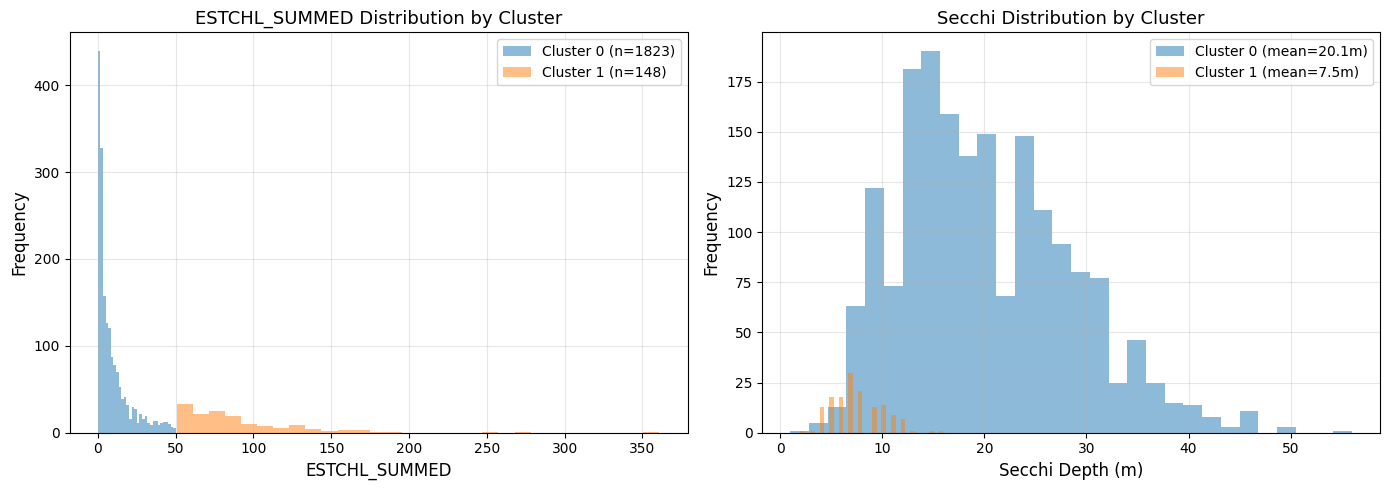

In [9]:
print("\n" + "="*80)
print("CLUSTERING BY ESTCHL_SUMMED")
print("="*80)

# Prepare data for clustering (just ESTCHL_SUMMED)
X_cluster = df[['ESTCHL_SUMMED']].copy()

# Standardize for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Perform K-means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['CLUSTER'] = kmeans.fit_predict(X_cluster_scaled)

# Get cluster statistics
for i in range(2):
    cluster_data = df[df['CLUSTER'] == i]
    print(f"\nCluster {i}:")
    print(f"  N = {len(cluster_data)}")
    print(f"  ESTCHL_SUMMED: {cluster_data['ESTCHL_SUMMED'].mean():.2f} ± {cluster_data['ESTCHL_SUMMED'].std():.2f}")
    print(f"  ESTCHL_SUMMED range: [{cluster_data['ESTCHL_SUMMED'].min():.2f}, {cluster_data['ESTCHL_SUMMED'].max():.2f}]")
    print(f"  Secchi: {cluster_data['Secchi'].mean():.2f} ± {cluster_data['Secchi'].std():.2f}")

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ESTCHL_SUMMED distribution by cluster
for i in range(2):
    cluster_data = df[df['CLUSTER'] == i]
    axes[0].hist(cluster_data['ESTCHL_SUMMED'], bins=30, alpha=0.5, 
                label=f'Cluster {i} (n={len(cluster_data)})')

axes[0].set_xlabel('ESTCHL_SUMMED', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('ESTCHL_SUMMED Distribution by Cluster', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Secchi distribution by cluster
for i in range(2):
    cluster_data = df[df['CLUSTER'] == i]
    axes[1].hist(cluster_data['Secchi'], bins=30, alpha=0.5,
                label=f'Cluster {i} (mean={cluster_data["Secchi"].mean():.1f}m)')

axes[1].set_xlabel('Secchi Depth (m)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Secchi Distribution by Cluster', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "estchl_clusters.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'estchl_clusters.png'}")
plt.show()

In [10]:
exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 
       'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'CLUSTER'  # Exclude cluster label
]

target_col = "Secchi"

feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]

print(f"\nFeatures for modeling: {feature_cols}")


Features for modeling: ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']


In [11]:
def train_all_models(data, feature_cols, target_col, cluster_name):
    """
    Train 4 different model types:
    1. Random Forest (simple)
    2. Random Forest (tuned with GridSearch)
    3. Gradient Boosting
    4. Ensemble (weighted average of all 3)
    """
    print(f"\n{'='*80}")
    print(f"TRAINING ALL MODELS FOR: {cluster_name}")
    print(f"{'='*80}")
    
    # Prepare data
    X = data[feature_cols].copy()
    y = data[target_col].copy()
    
    # Remove rows with missing target
    mask = y.notna() & (y > 0)
    X = X[mask]
    y = y[mask]
    
    print(f"\nSample size: {len(X)}")
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    
    X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
    X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)
    
    results = {}

    # ========================================================================
    # MODEL 1: Random Forest (Simple)
    # ========================================================================
    
    print(f"\n{'-'*60}")
    print("1. Random Forest (Simple)")
    print(f"{'-'*60}")
    
    rf_simple = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    # Cross-validation
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf_simple, X_train_imp, y_train, cv=kfold, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    cv_r2 = cross_val_score(rf_simple, X_train_imp, y_train, cv=kfold, scoring='r2')
    
    print(f"CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    
    # Train and evaluate
    rf_simple.fit(X_train_imp, y_train)
    y_test_pred_rf_simple = rf_simple.predict(X_test_imp)
    
    test_rmse_rf_simple = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_simple))
    test_r2_rf_simple = r2_score(y_test, y_test_pred_rf_simple)
    
    print(f"Test RMSE: {test_rmse_rf_simple:.4f}")
    print(f"Test R²:   {test_r2_rf_simple:.4f}")
    
    # Save
    joblib.dump(rf_simple, models_dir / f"{cluster_name}_rf_simple.joblib")
    
    results['rf_simple'] = {
        'model': rf_simple,
        'name': 'RF Simple',
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'test_rmse': test_rmse_rf_simple,
        'test_r2': test_r2_rf_simple,
        'y_pred': y_test_pred_rf_simple
    }
    
    # ========================================================================
    # MODEL 2: Random Forest (Tuned with GridSearch)
    # ========================================================================
    
    print(f"\n{'-'*60}")
    print("2. Random Forest (Tuned - GridSearchCV)")
    print(f"{'-'*60}")
    
    rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.3]
    }
    
    grid_search = GridSearchCV(
        rf_tuned,
        param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )
    
    print("Running GridSearchCV (this may take a while)...")
    grid_search.fit(X_train_imp, y_train)
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    
    rf_tuned_best = grid_search.best_estimator_
    
    # Evaluate
    y_test_pred_rf_tuned = rf_tuned_best.predict(X_test_imp)
    
    test_rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_tuned))
    test_r2_rf_tuned = r2_score(y_test, y_test_pred_rf_tuned)
    
    print(f"Test RMSE: {test_rmse_rf_tuned:.4f}")
    print(f"Test R²:   {test_r2_rf_tuned:.4f}")
    
    # Save
    joblib.dump(rf_tuned_best, models_dir / f"{cluster_name}_rf_tuned.joblib")
    
    results['rf_tuned'] = {
        'model': rf_tuned_best,
        'name': 'RF Tuned',
        'test_rmse': test_rmse_rf_tuned,
        'test_r2': test_r2_rf_tuned,
        'y_pred': y_test_pred_rf_tuned,
        'best_params': grid_search.best_params_
    }
    
    # ========================================================================
    # MODEL 3: Gradient Boosting
    # ========================================================================
    
    print(f"\n{'-'*60}")
    print("3. Gradient Boosting")
    print(f"{'-'*60}")
    
    gb = HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_depth=5,
        max_iter=300,
        min_samples_leaf=20,
        random_state=42
    )
    
    # Cross-validation
    cv_scores_gb = cross_val_score(gb, X_train_imp, y_train, cv=kfold, 
                                   scoring='neg_mean_squared_error')
    cv_rmse_gb = np.sqrt(-cv_scores_gb)
    cv_r2_gb = cross_val_score(gb, X_train_imp, y_train, cv=kfold, scoring='r2')
    
    print(f"CV RMSE: {cv_rmse_gb.mean():.4f} ± {cv_rmse_gb.std():.4f}")
    print(f"CV R²:   {cv_r2_gb.mean():.4f} ± {cv_r2_gb.std():.4f}")
    
    # Train and evaluate
    gb.fit(X_train_imp, y_train)
    y_test_pred_gb = gb.predict(X_test_imp)
    
    test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
    test_r2_gb = r2_score(y_test, y_test_pred_gb)
    
    print(f"Test RMSE: {test_rmse_gb:.4f}")
    print(f"Test R²:   {test_r2_gb:.4f}")
    
    # Save
    joblib.dump(gb, models_dir / f"{cluster_name}_gb.joblib")
    
    results['gb'] = {
        'model': gb,
        'name': 'Gradient Boosting',
        'cv_rmse': cv_rmse_gb,
        'cv_r2': cv_r2_gb,
        'test_rmse': test_rmse_gb,
        'test_r2': test_r2_gb,
        'y_pred': y_test_pred_gb
    }
    
    # ========================================================================
    # MODEL 4: Ensemble (Weighted Average)
    # ========================================================================
    
    print(f"\n{'-'*60}")
    print("4. Ensemble (Weighted Average)")
    print(f"{'-'*60}")
    
    # Weighted average of all 3 models
    y_test_pred_ensemble = (
        0.4 * y_test_pred_rf_simple +
        0.4 * y_test_pred_rf_tuned +
        0.2 * y_test_pred_gb
    )
    
    test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_test_pred_ensemble))
    test_r2_ensemble = r2_score(y_test, y_test_pred_ensemble)
    
    print(f"Test RMSE: {test_rmse_ensemble:.4f}")
    print(f"Test R²:   {test_r2_ensemble:.4f}")
    
    results['ensemble'] = {
        'name': 'Ensemble',
        'test_rmse': test_rmse_ensemble,
        'test_r2': test_r2_ensemble,
        'y_pred': y_test_pred_ensemble
    }
    
    # ========================================================================
    # Save common data
    # ========================================================================
    
    joblib.dump(imputer, models_dir / f"{cluster_name}_imputer.joblib")
    
    # Feature importance (from RF simple)
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_simple.feature_importances_
    }).sort_values('importance', ascending=False)
    
    feature_importance.to_csv(models_dir / f"{cluster_name}_feature_importance.csv", index=False)
    
    # Add shared data
    for key in results:
        results[key]['y_test'] = y_test
        results[key]['feature_importance'] = feature_importance
        results[key]['cluster_name'] = cluster_name
    
    return results

In [16]:
# ============================================================================
# TRAIN MODELS FOR EACH CLUSTER
# ============================================================================

all_results = {}

# Cluster 0
cluster_0_df = df[df['CLUSTER'] == 0]
if len(cluster_0_df) > 50:
    all_results['cluster_0'] = train_all_models(
        cluster_0_df, feature_cols, target_col, "cluster_0"
    )

# Cluster 1
cluster_1_df = df[df['CLUSTER'] == 1]
if len(cluster_1_df) > 50:
    all_results['cluster_1'] = train_all_models(
        cluster_1_df, feature_cols, target_col, "cluster_1"
    )

# Overall (for comparison)
print("\n" + "="*80)
print("OVERALL (ALL DATA - FOR COMPARISON)")
print("="*80)

all_results['overall'] = train_all_models(
    df, feature_cols, target_col, "overall"
)



TRAINING ALL MODELS FOR: cluster_0

Sample size: 1823
Train: 1458, Test: 365

------------------------------------------------------------
1. Random Forest (Simple)
------------------------------------------------------------
CV RMSE: 4.4359 ± 0.1731
CV R²:   0.7213 ± 0.0176
Test RMSE: 4.0412
Test R²:   0.7661

------------------------------------------------------------
2. Random Forest (Tuned - GridSearchCV)
------------------------------------------------------------
Running GridSearchCV (this may take a while)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible


Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Test RMSE: 4.1190
Test R²:   0.7570

------------------------------------------------------------
3. Gradient Boosting
------------------------------------------------------------
CV RMSE: 4.6536 ± 0.1961
CV R²:   0.6933 ± 0.0203
Test RMSE: 4.2551
Test R²:   0.7407

------------------------------------------------------------
4. Ensemble (Weighted Average)
------------------------------------------------------------
Test RMSE: 4.0466
Test R²:   0.7655

TRAINING ALL MODELS FOR: cluster_1

Sample size: 148
Train: 118, Test: 30

------------------------------------------------------------
1. Random Forest (Simple)
------------------------------------------------------------
CV RMSE: 2.0163 ± 0.2412
CV R²:   0.2998 ± 0.1375
Test RMSE: 1.9383
Test R²:   0.3297

------------------------------------------------------------
2. Random Forest (Tuned - GridSearchCV)
---


COMPREHENSIVE MODEL COMPARISON

  Cluster             Model  Test_R2  Test_RMSE    CV_R2  CV_RMSE
cluster_0         RF Simple 0.766126   4.041165 0.721337 4.435856
cluster_0          Ensemble 0.765491   4.046648      NaN      NaN
cluster_0          RF Tuned 0.757029   4.119014      NaN      NaN
  overall          Ensemble 0.754672   4.362836      NaN      NaN
  overall         RF Simple 0.750807   4.397069 0.765783 4.218937
  overall          RF Tuned 0.750303   4.401513      NaN      NaN
  overall Gradient Boosting 0.743040   4.465070 0.745771 4.395124
cluster_0 Gradient Boosting 0.740713   4.255065 0.693340 4.653561
cluster_1 Gradient Boosting 0.472456   1.719644 0.128393 2.248665
cluster_1          RF Tuned 0.434167   1.780958      NaN      NaN
cluster_1          Ensemble 0.433475   1.782046      NaN      NaN
cluster_1         RF Simple 0.329739   1.938345 0.299763 2.016280

Summary saved to: ../results/comprehensive_model_comparison.csv

CREATING VISUALIZATIONS
Saved: ../results/a

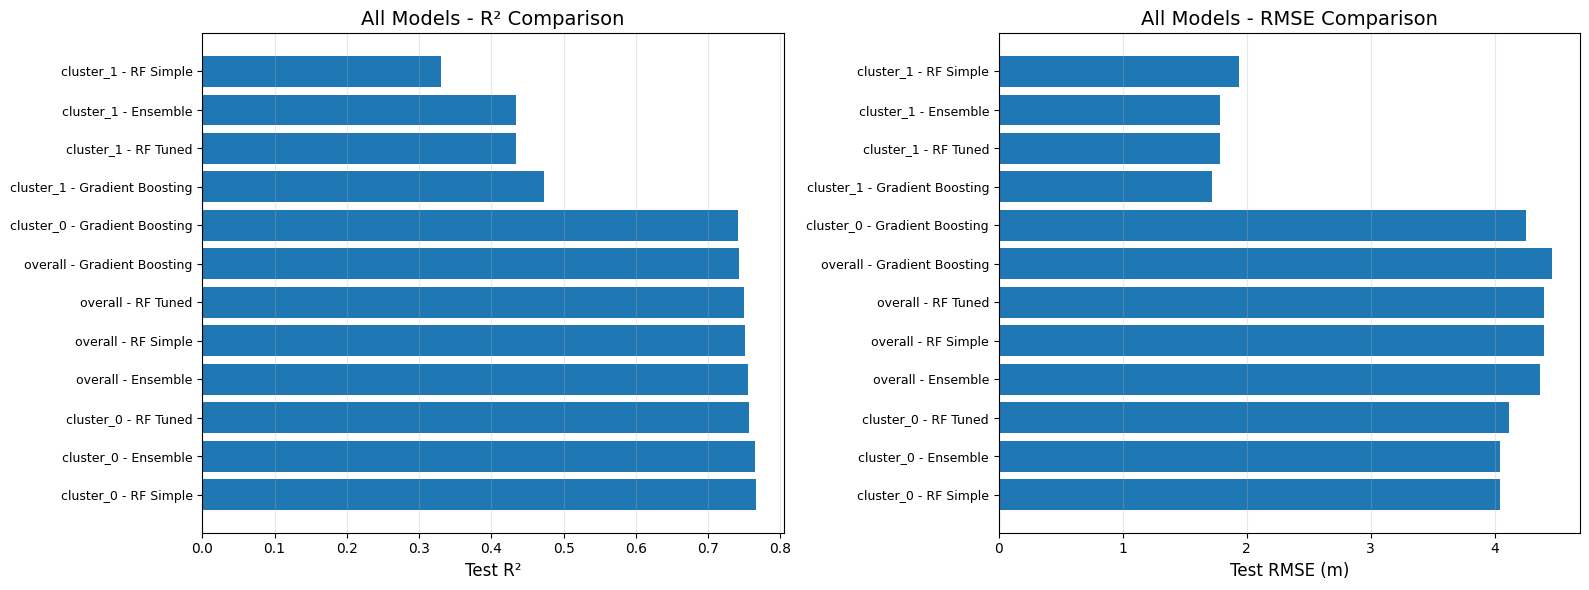

Saved: ../results/best_cluster_predictions.png


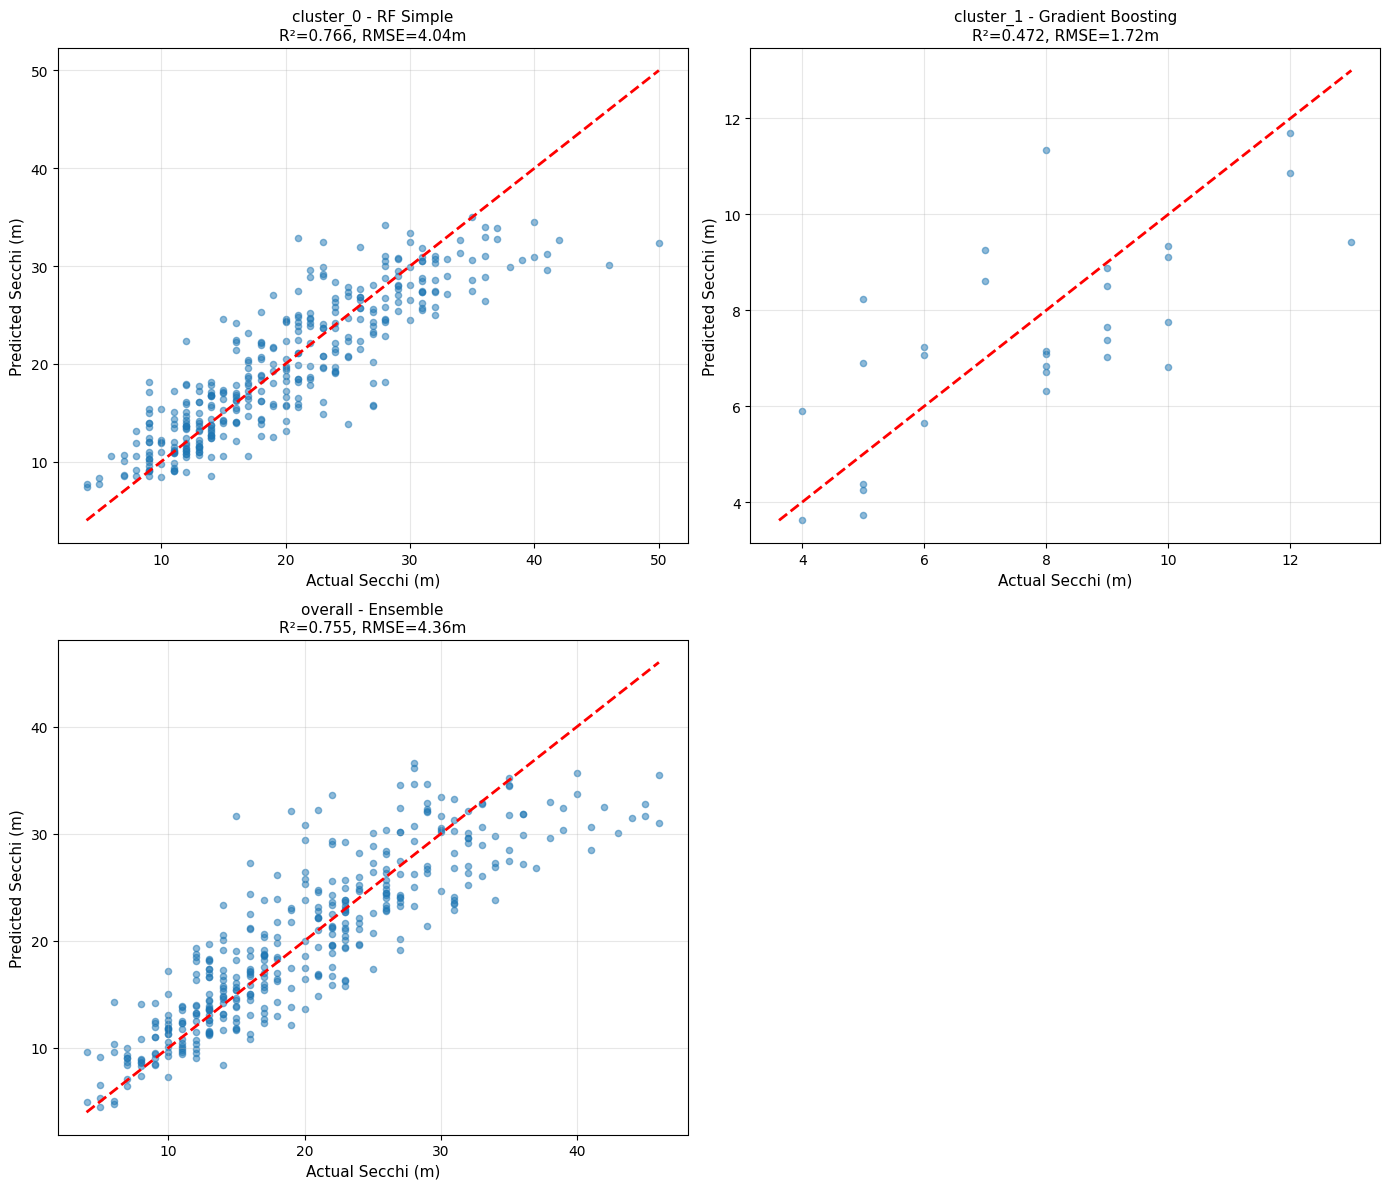


FINAL RECOMMENDATION

Best Overall Model:
  cluster_0 - RF Simple
  Test R²: 0.7661
  Test RMSE: 4.0412

ANALYSIS COMPLETE!

All models saved to: ../Models
All results saved to: ../results


In [17]:
# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

summary_data = []

for cluster_key, cluster_results in all_results.items():
    for model_key, model_data in cluster_results.items():
        summary_data.append({
            'Cluster': cluster_key,
            'Model': model_data['name'],
            'Test_R2': model_data['test_r2'],
            'Test_RMSE': model_data['test_rmse'],
            'CV_R2': model_data.get('cv_r2', pd.Series([np.nan])).mean() if 'cv_r2' in model_data else np.nan,
            'CV_RMSE': model_data.get('cv_rmse', pd.Series([np.nan])).mean() if 'cv_rmse' in model_data else np.nan
        })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test_R2', ascending=False)

print(f"\n{summary_df.to_string(index=False)}")

# Save
summary_df.to_csv(results_dir / "comprehensive_model_comparison.csv", index=False)
print(f"\nSummary saved to: {results_dir / 'comprehensive_model_comparison.csv'}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Plot 1: Overall Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
clusters = summary_df['Cluster'] + ' - ' + summary_df['Model']
test_r2 = summary_df['Test_R2']

axes[0].barh(range(len(clusters)), test_r2)
axes[0].set_yticks(range(len(clusters)))
axes[0].set_yticklabels(clusters, fontsize=9)
axes[0].set_xlabel('Test R²', fontsize=12)
axes[0].set_title('All Models - R² Comparison', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

# RMSE comparison
test_rmse = summary_df['Test_RMSE']

axes[1].barh(range(len(clusters)), test_rmse)
axes[1].set_yticks(range(len(clusters)))
axes[1].set_yticklabels(clusters, fontsize=9)
axes[1].set_xlabel('Test RMSE (m)', fontsize=12)
axes[1].set_title('All Models - RMSE Comparison', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(results_dir / "all_models_performance.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'all_models_performance.png'}")
plt.show()

# Plot 2: Best model from each cluster - Actual vs Predicted
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

plot_idx = 0
for cluster_key in ['cluster_0', 'cluster_1', 'overall']:
    if cluster_key in all_results:
        # Find best model for this cluster
        cluster_summary = summary_df[summary_df['Cluster'] == cluster_key]
        best_model_name = cluster_summary.iloc[0]['Model']
        
        # Get the corresponding result
        for model_key, model_data in all_results[cluster_key].items():
            if model_data['name'] == best_model_name:
                axes[plot_idx].scatter(model_data['y_test'], model_data['y_pred'], 
                                     alpha=0.5, s=20)
                
                min_val = min(model_data['y_test'].min(), model_data['y_pred'].min())
                max_val = max(model_data['y_test'].max(), model_data['y_pred'].max())
                
                axes[plot_idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
                axes[plot_idx].set_xlabel('Actual Secchi (m)', fontsize=11)
                axes[plot_idx].set_ylabel('Predicted Secchi (m)', fontsize=11)
                axes[plot_idx].set_title(f'{cluster_key} - {best_model_name}\nR²={model_data["test_r2"]:.3f}, RMSE={model_data["test_rmse"]:.2f}m', 
                                        fontsize=11)
                axes[plot_idx].grid(True, alpha=0.3)
                
                plot_idx += 1
                break

# Hide unused subplot
axes[3].axis('off')

plt.tight_layout()
plt.savefig(results_dir / "best_cluster_predictions.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'best_cluster_predictions.png'}")
plt.show()

# ============================================================================
# FINAL RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)

# Find overall best model
best_overall = summary_df.iloc[0]
print(f"\nBest Overall Model:")
print(f"  {best_overall['Cluster']} - {best_overall['Model']}")
print(f"  Test R²: {best_overall['Test_R2']:.4f}")
print(f"  Test RMSE: {best_overall['Test_RMSE']:.4f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nAll models saved to: {models_dir}")
print(f"All results saved to: {results_dir}")

Loading data...
Total observations: 1971

CREATING MULTIPLE CLUSTERING SCHEMES

Clustering by ESTCHL_SUMMED:
  Cluster 0: n=1823, ESTCHL_SUMMED mean=9.32
  Cluster 1: n=148, ESTCHL_SUMMED mean=91.54

Clustering by XMISS_SUMMED:
  Cluster 0: n=1534, XMISS_SUMMED mean=1571.33
  Cluster 1: n=437, XMISS_SUMMED mean=190.50

Clustering by SPAR + ESTCHL_SUMMED:
  Cluster 0: n=1677, SPAR mean=-863829099581775.50, ESTCHL_SUMMED mean=15.36
  Cluster 1: n=116, SPAR mean=-133476465517241376.00, ESTCHL_SUMMED mean=21.06

Saved: ../results/all_clustering_schemes.png


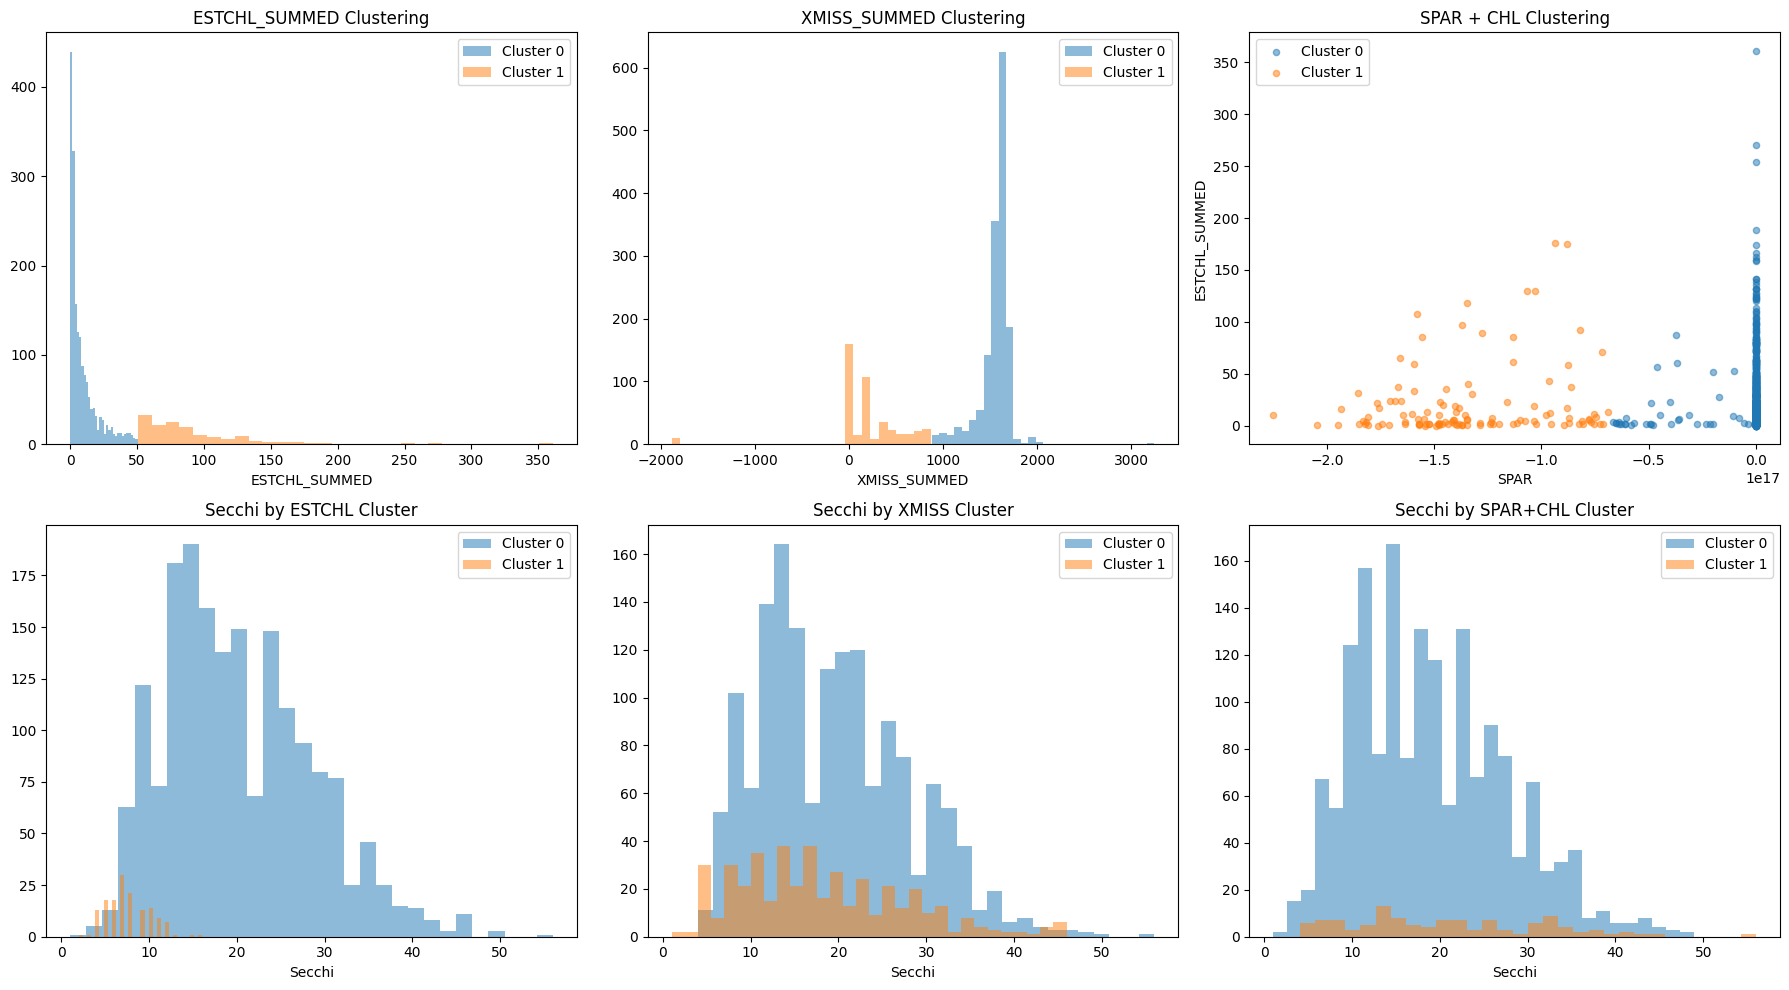


Base features: ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']

BASELINE: NO CLUSTER FEATURES

TRAINING: baseline_no_clusters

Features used: ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']
Sample size: 1971

CV RMSE: 4.2189 ± 0.2761
CV R²:   0.7658 ± 0.0183

Test RMSE: 4.3971
Test R²:   0.7508

Top 10 Features (including cluster features):
       feature  importance
 ESTCHL_SUMMED    0.589189
  CHL_A_SUMMED    0.173599
   K_PAR_SLOPE    0.056091
ESTCHL_STACORR    0.039182
  XMISS_SUMMED    0.033380
         K_PAR    0.031349
       Lat_Dec    0.018367
       Lon_Dec    0.018171
  PHAEO_SUMMED    0.014792
         DEPTH    0.013108

TRAINING: with_estchl_cluster

Features used: ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_S

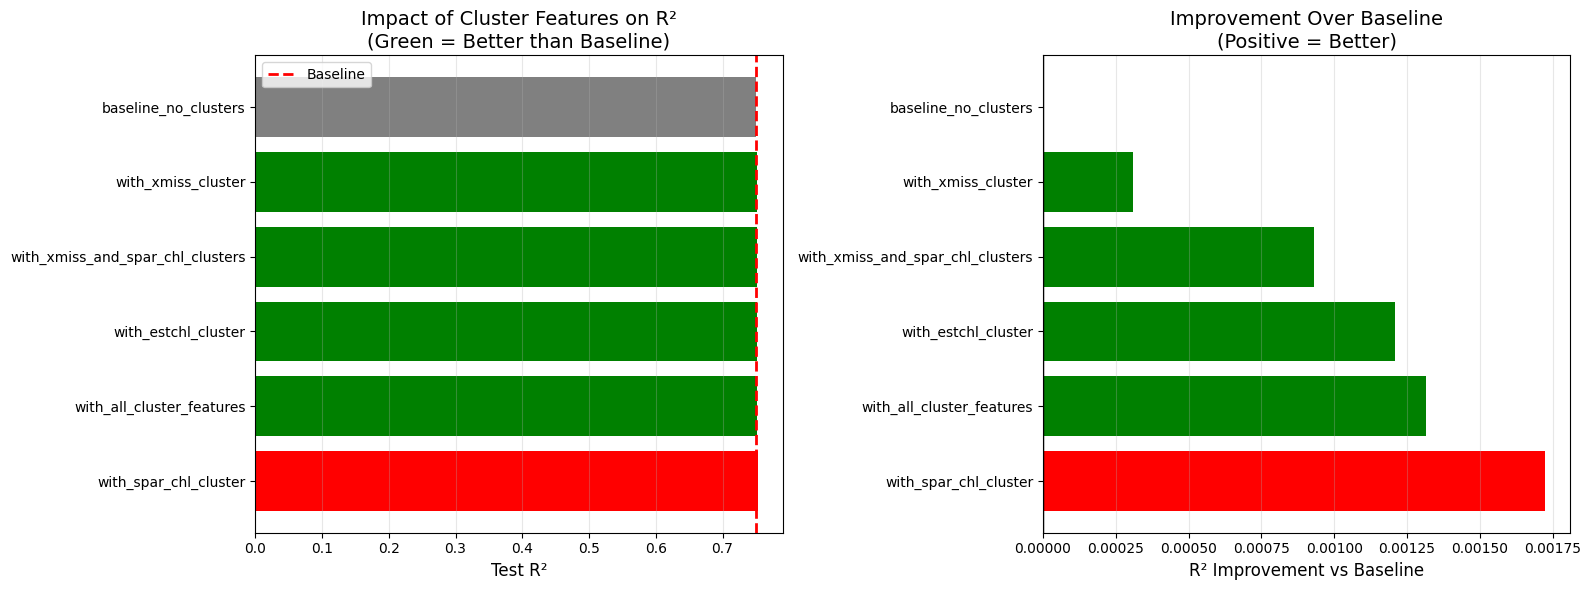


RECOMMENDATION

Baseline (no cluster features): R² = 0.7508
Best model: with_spar_chl_cluster
Best R²: 0.7525
Improvement: 0.0017 (0.17%)

✗ Cluster features don't provide meaningful improvement
  Stick with baseline model

ANALYSIS COMPLETE!


In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from scipy import stats as scipy_stats
import joblib

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

# Remove rows with missing Secchi
df = df[df['Secchi'].notna()].copy()

print(f"Total observations: {len(df)}")

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# ============================================================================
# CREATE MULTIPLE CLUSTERING SCHEMES
# ============================================================================

print("\n" + "="*80)
print("CREATING MULTIPLE CLUSTERING SCHEMES")
print("="*80)

scaler = StandardScaler()

# Clustering Scheme 1: ESTCHL_SUMMED (your original)
if 'ESTCHL_SUMMED' in df.columns and df['ESTCHL_SUMMED'].notna().sum() > 100:
    X_estchl = df[['ESTCHL_SUMMED']].dropna()
    X_estchl_scaled = scaler.fit_transform(X_estchl)
    kmeans_estchl = KMeans(n_clusters=2, random_state=42, n_init=10)
    
    # Initialize with NaN
    df['CLUSTER_ESTCHL'] = np.nan
    # Assign cluster labels only to rows with valid ESTCHL_SUMMED
    df.loc[X_estchl.index, 'CLUSTER_ESTCHL'] = kmeans_estchl.fit_predict(X_estchl_scaled)
    
    print(f"\nClustering by ESTCHL_SUMMED:")
    for i in range(2):
        cluster_data = df[df['CLUSTER_ESTCHL'] == i]
        print(f"  Cluster {i}: n={len(cluster_data)}, ESTCHL_SUMMED mean={cluster_data['ESTCHL_SUMMED'].mean():.2f}")

# Clustering Scheme 2: XMISS_SUMMED
if 'XMISS_SUMMED' in df.columns and df['XMISS_SUMMED'].notna().sum() > 100:
    X_xmiss = df[['XMISS_SUMMED']].dropna()
    X_xmiss_scaled = scaler.fit_transform(X_xmiss)
    kmeans_xmiss = KMeans(n_clusters=2, random_state=42, n_init=10)
    
    df['CLUSTER_XMISS'] = np.nan
    df.loc[X_xmiss.index, 'CLUSTER_XMISS'] = kmeans_xmiss.fit_predict(X_xmiss_scaled)
    
    print(f"\nClustering by XMISS_SUMMED:")
    for i in range(2):
        cluster_data = df[df['CLUSTER_XMISS'] == i]
        print(f"  Cluster {i}: n={len(cluster_data)}, XMISS_SUMMED mean={cluster_data['XMISS_SUMMED'].mean():.2f}")

# Clustering Scheme 3: SPAR + ESTCHL_SUMMED
if 'SPAR' in df.columns and 'ESTCHL_SUMMED' in df.columns:
    X_spar_chl = df[['SPAR', 'ESTCHL_SUMMED']].dropna()
    if len(X_spar_chl) > 100:
        X_spar_chl_scaled = scaler.fit_transform(X_spar_chl)
        kmeans_spar_chl = KMeans(n_clusters=2, random_state=42, n_init=10)
        
        df['CLUSTER_SPAR_CHL'] = np.nan
        df.loc[X_spar_chl.index, 'CLUSTER_SPAR_CHL'] = kmeans_spar_chl.fit_predict(X_spar_chl_scaled)
        
        print(f"\nClustering by SPAR + ESTCHL_SUMMED:")
        for i in range(2):
            cluster_data = df[df['CLUSTER_SPAR_CHL'] == i]
            print(f"  Cluster {i}: n={len(cluster_data)}, SPAR mean={cluster_data['SPAR'].mean():.2f}, ESTCHL_SUMMED mean={cluster_data['ESTCHL_SUMMED'].mean():.2f}")

# ============================================================================
# VISUALIZE CLUSTERING SCHEMES
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot ESTCHL clustering
if 'CLUSTER_ESTCHL' in df.columns:
    for i in range(2):
        cluster_data = df[df['CLUSTER_ESTCHL'] == i]
        axes[0, 0].hist(cluster_data['ESTCHL_SUMMED'], bins=30, alpha=0.5, label=f'Cluster {i}')
    axes[0, 0].set_title('ESTCHL_SUMMED Clustering')
    axes[0, 0].set_xlabel('ESTCHL_SUMMED')
    axes[0, 0].legend()
    
    for i in range(2):
        cluster_data = df[df['CLUSTER_ESTCHL'] == i]
        axes[1, 0].hist(cluster_data['Secchi'], bins=30, alpha=0.5, label=f'Cluster {i}')
    axes[1, 0].set_title('Secchi by ESTCHL Cluster')
    axes[1, 0].set_xlabel('Secchi')
    axes[1, 0].legend()

# Plot XMISS clustering
if 'CLUSTER_XMISS' in df.columns:
    for i in range(2):
        cluster_data = df[df['CLUSTER_XMISS'] == i]
        axes[0, 1].hist(cluster_data['XMISS_SUMMED'], bins=30, alpha=0.5, label=f'Cluster {i}')
    axes[0, 1].set_title('XMISS_SUMMED Clustering')
    axes[0, 1].set_xlabel('XMISS_SUMMED')
    axes[0, 1].legend()
    
    for i in range(2):
        cluster_data = df[df['CLUSTER_XMISS'] == i]
        axes[1, 1].hist(cluster_data['Secchi'], bins=30, alpha=0.5, label=f'Cluster {i}')
    axes[1, 1].set_title('Secchi by XMISS Cluster')
    axes[1, 1].set_xlabel('Secchi')
    axes[1, 1].legend()

# Plot SPAR+CHL clustering
if 'CLUSTER_SPAR_CHL' in df.columns:
    for i in range(2):
        cluster_data = df[df['CLUSTER_SPAR_CHL'] == i]
        axes[0, 2].scatter(cluster_data['SPAR'], cluster_data['ESTCHL_SUMMED'], 
                          alpha=0.5, s=20, label=f'Cluster {i}')
    axes[0, 2].set_title('SPAR + CHL Clustering')
    axes[0, 2].set_xlabel('SPAR')
    axes[0, 2].set_ylabel('ESTCHL_SUMMED')
    axes[0, 2].legend()
    
    for i in range(2):
        cluster_data = df[df['CLUSTER_SPAR_CHL'] == i]
        axes[1, 2].hist(cluster_data['Secchi'], bins=30, alpha=0.5, label=f'Cluster {i}')
    axes[1, 2].set_title('Secchi by SPAR+CHL Cluster')
    axes[1, 2].set_xlabel('Secchi')
    axes[1, 2].legend()

plt.tight_layout()
plt.savefig(results_dir / "all_clustering_schemes.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'all_clustering_schemes.png'}")
plt.show()

# ============================================================================
# DEFINE FEATURES AND TARGET
# ============================================================================

exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 
       'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       # Don't exclude cluster columns - we'll add them as features
]

target_col = "Secchi"

base_feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col] 
                     and not col.startswith('CLUSTER_')]

print(f"\nBase features: {base_feature_cols}")

# ============================================================================
# FUNCTION TO TRAIN MODEL WITH CLUSTER FEATURES
# ============================================================================

def train_with_cluster_features(data, base_features, cluster_cols, target_col, model_name):
    """
    Train a Random Forest model with cluster membership as additional features
    """
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    
    # Combine base features with cluster features
    all_features = base_features + cluster_cols
    
    # Remove rows with missing features
    X = data[all_features].copy()
    y = data[target_col].copy()
    
    mask = y.notna() & (y > 0)
    X = X[mask]
    y = y[mask]
    
    print(f"\nFeatures used: {all_features}")
    print(f"Sample size: {len(X)}")
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Impute
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    
    X_train_imp = pd.DataFrame(X_train_imp, columns=all_features, index=X_train.index)
    X_test_imp = pd.DataFrame(X_test_imp, columns=all_features, index=X_test.index)
    
    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    # CV
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X_train_imp, y_train, cv=kfold, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    cv_r2 = cross_val_score(rf, X_train_imp, y_train, cv=kfold, scoring='r2')
    
    print(f"\nCV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    
    # Train
    rf.fit(X_train_imp, y_train)
    
    # Test
    y_test_pred = rf.predict(X_test_imp)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nTest RMSE: {test_rmse:.4f}")
    print(f"Test R²:   {test_r2:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': all_features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 10 Features (including cluster features):")
    print(feature_importance.head(10).to_string(index=False))
    
    # Highlight cluster feature importance
    cluster_importance = feature_importance[feature_importance['feature'].isin(cluster_cols)]
    if len(cluster_importance) > 0:
        print(f"\nCluster Feature Importance:")
        print(cluster_importance.to_string(index=False))
    
    # Save
    joblib.dump(rf, models_dir / f"{model_name}.joblib")
    feature_importance.to_csv(models_dir / f"{model_name}_importance.csv", index=False)
    
    return {
        'model': rf,
        'name': model_name,
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'feature_importance': feature_importance
    }

# ============================================================================
# TRAIN MODELS WITH DIFFERENT CLUSTER FEATURE COMBINATIONS
# ============================================================================

results = {}

# Baseline: No cluster features
print("\n" + "="*80)
print("BASELINE: NO CLUSTER FEATURES")
print("="*80)

results['baseline'] = train_with_cluster_features(
    df, base_feature_cols, [], target_col, "baseline_no_clusters"
)

# Model 1: With ESTCHL cluster
if 'CLUSTER_ESTCHL' in df.columns:
    results['with_estchl_cluster'] = train_with_cluster_features(
        df, base_feature_cols, ['CLUSTER_ESTCHL'], target_col, "with_estchl_cluster"
    )

# Model 2: With XMISS cluster
if 'CLUSTER_XMISS' in df.columns:
    results['with_xmiss_cluster'] = train_with_cluster_features(
        df, base_feature_cols, ['CLUSTER_XMISS'], target_col, "with_xmiss_cluster"
    )

# Model 3: With SPAR+CHL cluster
if 'CLUSTER_SPAR_CHL' in df.columns:
    results['with_spar_chl_cluster'] = train_with_cluster_features(
        df, base_feature_cols, ['CLUSTER_SPAR_CHL'], target_col, "with_spar_chl_cluster"
    )

# Model 4: With XMISS cluster + SPAR_CHL cluster (your colleague's approach)
if 'CLUSTER_XMISS' in df.columns and 'CLUSTER_SPAR_CHL' in df.columns:
    results['with_xmiss_and_spar_chl'] = train_with_cluster_features(
        df, base_feature_cols, ['CLUSTER_XMISS', 'CLUSTER_SPAR_CHL'], target_col, 
        "with_xmiss_and_spar_chl_clusters"
    )

# Model 5: With all cluster features
cluster_features_available = [col for col in ['CLUSTER_ESTCHL', 'CLUSTER_XMISS', 'CLUSTER_SPAR_CHL'] 
                              if col in df.columns]
if len(cluster_features_available) > 1:
    results['with_all_clusters'] = train_with_cluster_features(
        df, base_feature_cols, cluster_features_available, target_col, 
        "with_all_cluster_features"
    )

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON: IMPACT OF CLUSTER FEATURES")
print("="*80)

summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model': res['name'],
        'CV_R2': res['cv_r2'].mean(),
        'CV_RMSE': res['cv_rmse'].mean(),
        'Test_R2': res['test_r2'],
        'Test_RMSE': res['test_rmse'],
        'Improvement_vs_Baseline': res['test_r2'] - results['baseline']['test_r2']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test_R2', ascending=False)

print(f"\n{summary_df.to_string(index=False)}")

# Save
summary_df.to_csv(results_dir / "cluster_features_comparison.csv", index=False)

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² comparison
models = summary_df['Model']
test_r2 = summary_df['Test_R2']
colors = ['red' if i == 0 else 'green' if x > results['baseline']['test_r2'] else 'gray' 
          for i, x in enumerate(test_r2)]

axes[0].barh(range(len(models)), test_r2, color=colors)
axes[0].set_yticks(range(len(models)))
axes[0].set_yticklabels(models, fontsize=10)
axes[0].set_xlabel('Test R²', fontsize=12)
axes[0].set_title('Impact of Cluster Features on R²\n(Green = Better than Baseline)', fontsize=14)
axes[0].axvline(results['baseline']['test_r2'], color='red', linestyle='--', 
               linewidth=2, label='Baseline')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Improvement over baseline
improvements = summary_df['Improvement_vs_Baseline']
colors2 = ['red' if i == 0 else 'green' if x > 0 else 'orange' for i, x in enumerate(improvements)]

axes[1].barh(range(len(models)), improvements, color=colors2)
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(models, fontsize=10)
axes[1].set_xlabel('R² Improvement vs Baseline', fontsize=12)
axes[1].set_title('Improvement Over Baseline\n(Positive = Better)', fontsize=14)
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(results_dir / "cluster_features_impact.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'cluster_features_impact.png'}")
plt.show()

# ============================================================================
# RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

best_model = summary_df.iloc[0]
baseline_r2 = results['baseline']['test_r2']
best_r2 = best_model['Test_R2']
improvement = best_r2 - baseline_r2

print(f"\nBaseline (no cluster features): R² = {baseline_r2:.4f}")
print(f"Best model: {best_model['Model']}")
print(f"Best R²: {best_r2:.4f}")
print(f"Improvement: {improvement:.4f} ({improvement*100:.2f}%)")

if improvement > 0.02:
    print(f"\n✓ RECOMMENDATION: Use cluster features!")
    print(f"  Adding cluster membership features improves R² by {improvement*100:.2f}%")
    print(f"  Best configuration: {best_model['Model']}")
elif improvement > 0.01:
    print(f"\n~ MODERATE improvement with cluster features")
    print(f"  Consider using: {best_model['Model']}")
else:
    print(f"\n✗ Cluster features don't provide meaningful improvement")
    print(f"  Stick with baseline model")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)